In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

XAI_PATH = "Data/xai_ig_ff3_vs_nn_2024_strict_train.parquet"

FIRM_PERF_PATH = "Data/firm_level_performance_2024.parquet"   #  contains permno + delta_r2 and/or delta_mspe
FIRM_SECTOR_PATH = "Data/firm_level_sector_2024.parquet"      # contains permno + sector_ff12

IMPROVE_COL = "delta_r2"         


FEATURE_COLS_ABS = ["ig_abs_mktrf", "ig_abs_smb", "ig_abs_hml"]
FEATURE_LABELS = ["MKT", "SMB", "HML"]

In [2]:
xai = pd.read_parquet(XAI_PATH)
firm_perf = pd.read_parquet(FIRM_PERF_PATH)

print("xai:", xai.shape, " firm_perf:", firm_perf.shape)
xai.head()


firm_sector = pd.read_parquet(FIRM_SECTOR_PATH)
print("firm_sector:", firm_sector.shape)

df = xai.merge(firm_perf, on="permno", how="inner")
df = df.merge(firm_sector.drop_duplicates("permno"), on="permno", how="left")

print("Merged df:", df.shape)

#defining improver
df["improver"] = df[IMPROVE_COL] > 0
df["improver"].value_counts(dropna=False)

xai: (2716, 8)  firm_perf: (2716, 2)
firm_sector: (2716, 2)
Merged df: (2716, 10)


improver
False    1813
True      903
Name: count, dtype: Int64

In [3]:
#normalizing
abs_attr = df[FEATURE_COLS_ABS].copy()
row_sum = abs_attr.sum(axis=1).replace(0, np.nan)

df["share_mktrf"] = abs_attr["ig_abs_mktrf"] / row_sum
df["share_smb"]   = abs_attr["ig_abs_smb"]   / row_sum
df["share_hml"]   = abs_attr["ig_abs_hml"]   / row_sum

SHARE_COLS = ["share_mktrf", "share_smb", "share_hml"]
df[SHARE_COLS].describe()

,share_mktrf,share_smb,share_hml
count,2716.000000,2716.000000,2716.000000
mean,0.433254,0.360671,0.206075
std,0.130741,0.135584,0.095507
min,0.070008,0.041314,0.027400
25%,0.343612,0.279109,0.127146
50%,0.420160,0.372627,0.197571
75%,0.509773,0.450816,0.271199
max,0.867329,0.792017,0.511332


In [4]:
group_means = df.groupby("improver")[FEATURE_COLS_ABS + SHARE_COLS].mean()
group_means


,ig_abs_mktrf,ig_abs_smb,ig_abs_hml,share_mktrf,share_smb,share_hml
improver,,,,,,
False,0.18142,0.138954,0.090800,0.432000,0.358891,0.209109
True,0.17779,0.137466,0.084669,0.435772,0.364244,0.199984


In [5]:
corr = df[[IMPROVE_COL] + FEATURE_COLS_ABS + SHARE_COLS].corr(numeric_only=True)[IMPROVE_COL]
corr.sort_values()

share_hml      -0.070455
ig_abs_hml     -0.013054
ig_abs_mktrf    0.013374
share_mktrf     0.021091
share_smb       0.029292
ig_abs_smb      0.057276
delta_r2        1.000000
Name: delta_r2, dtype: float64

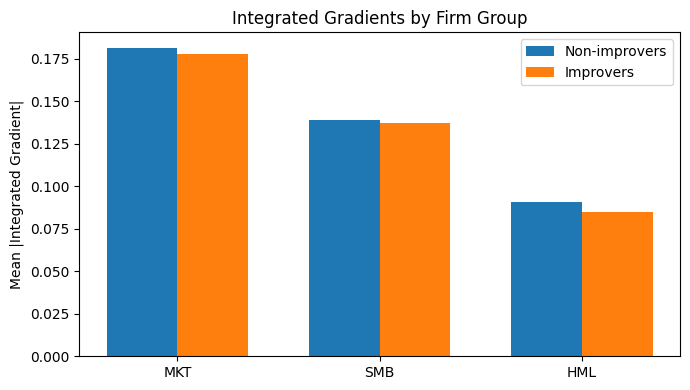

In [6]:
means = df.groupby("improver")[FEATURE_COLS_ABS].mean()

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(FEATURE_LABELS))
width = 0.35

ax.bar(x - width/2, means.loc[False].values, width, label="Non-improvers")
ax.bar(x + width/2, means.loc[True].values,  width, label="Improvers")

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_LABELS)
ax.set_ylabel("Mean |Integrated Gradient|")
ax.set_title("Integrated Gradients by Firm Group")
ax.legend()
plt.tight_layout()
plt.show()

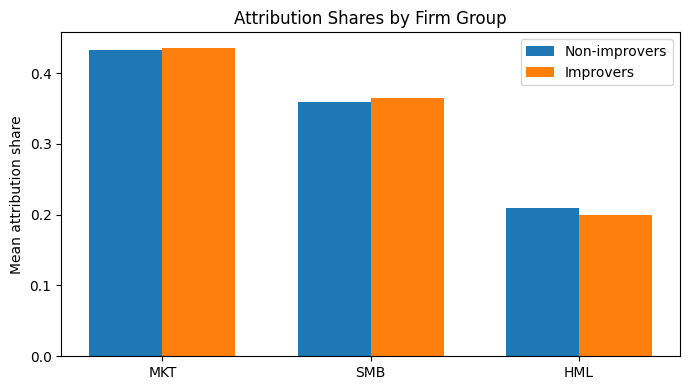

In [7]:
means_share = df.groupby("improver")[SHARE_COLS].mean()

fig, ax = plt.subplots(figsize=(7,4))
x = np.arange(len(FEATURE_LABELS))
width = 0.35

ax.bar(x - width/2, means_share.loc[False].values, width, label="Non-improvers")
ax.bar(x + width/2, means_share.loc[True].values,  width, label="Improvers")

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_LABELS)
ax.set_ylabel("Mean attribution share")
ax.set_title("Attribution Shares by Firm Group")
ax.legend()
plt.tight_layout()
plt.show()

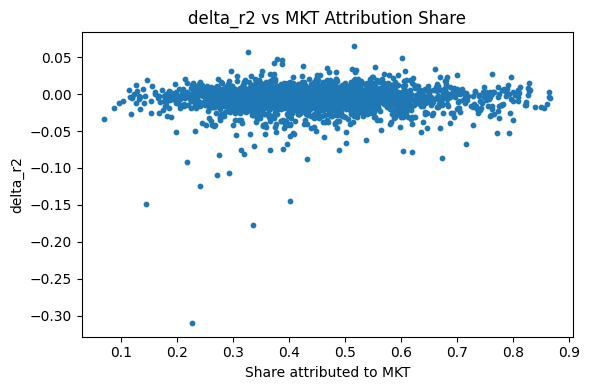

In [8]:
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(df["share_mktrf"], df[IMPROVE_COL], s=10)
ax.set_xlabel("Share attributed to MKT")
ax.set_ylabel(IMPROVE_COL)
ax.set_title(f"{IMPROVE_COL} vs MKT Attribution Share")
plt.tight_layout()
plt.show()

In [ ]:
sector_means = df.groupby("sector_ff12")[SHARE_COLS].mean().sort_index()
sector_means

,share_mktrf,share_smb,share_hml
sector_ff12,,,
BusEq,0.493626,0.346595,0.159779
Chems,0.507642,0.288385,0.203973
Cnsmr,0.478428,0.337261,0.184311
Durbl,0.444589,0.351403,0.204007
Enrgy,0.403309,0.272489,0.324202
Hlth,0.390805,0.441530,0.167665
Manuf,0.464109,0.321967,0.213924
Money,0.401524,0.300618,0.297858
Other,0.402878,0.413875,0.183248


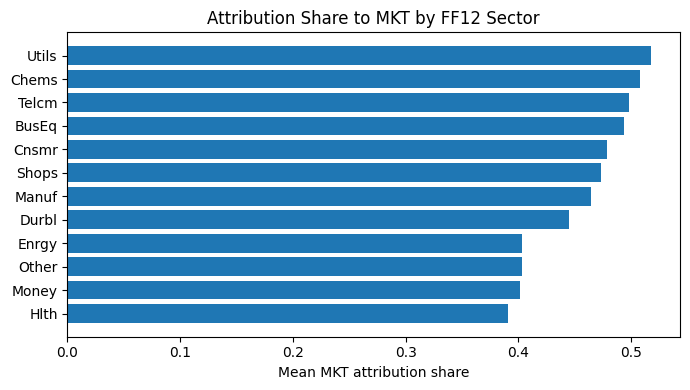

In [10]:
sector_means = df.groupby("sector_ff12")[SHARE_COLS].mean().sort_values("share_mktrf")

fig, ax = plt.subplots(figsize=(7,4))
ax.barh(sector_means.index, sector_means["share_mktrf"].values)
ax.set_xlabel("Mean MKT attribution share")
ax.set_title("Attribution Share to MKT by FF12 Sector")
plt.tight_layout()
plt.show()

In [11]:
def winsorize(s, p=0.01):
    lo, hi = s.quantile(p), s.quantile(1-p)
    return s.clip(lo, hi)

df["delta_w"] = winsorize(df[IMPROVE_COL], p=0.01)

df[[ "delta_w" ] + SHARE_COLS].corr(numeric_only=True)["delta_w"].sort_values()

share_hml     -0.064432
share_mktrf   -0.001909
share_smb      0.047228
delta_w        1.000000
Name: delta_w, dtype: float64

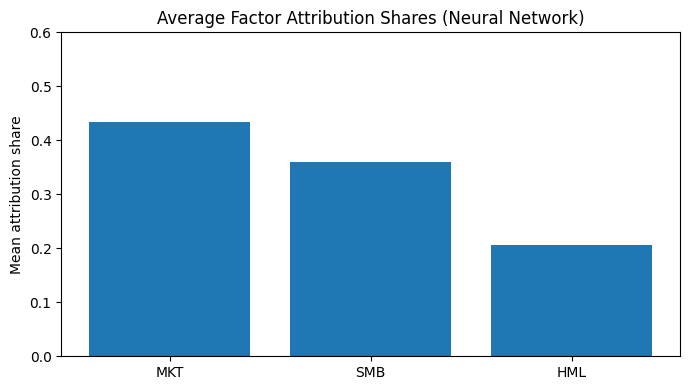

In [12]:
overall_means = df[SHARE_COLS].mean()

labels = ["MKT", "SMB", "HML"]
values = overall_means.values

# Plot
fig, ax = plt.subplots(figsize=(7,4))

x = np.arange(len(labels))
ax.bar(x, values)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Mean attribution share")
ax.set_title("Average Factor Attribution Shares (Neural Network)")
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.show()